# Final Result Evaluation: Portfolio Analysis and Factor Regressions
This script performs portfolio analysis for the sentiment-based trading strategies. 
It evaluates performance and risk metrics of sentiment-based portfolios using standard factor models (CAPM, Fama–French three- and five-factor models) and 
conducts a Fama–MacBeth regression to test cross-sectional risk pricing.

In [87]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [119]:
df = pd.read_csv("daily_sentiment_return.csv")
df

,date,TICKER,PRC,RET,SHROUT,MV_USD,MV_USD_lag,Ticker,date_day,sentiment_daily
0,2024-07-01,A,127.40000,-0.017203,291761.0,3.717035e+07,3.782098e+07,A,2024-07-01,1.0
1,2024-07-16,A,136.06000,0.038547,291761.0,3.969700e+07,3.822361e+07,A,2024-07-16,-1.0
2,2024-07-19,A,131.78000,-0.001440,291761.0,3.844826e+07,3.850370e+07,A,2024-07-19,-1.0
3,2024-07-22,A,133.42000,0.012445,291761.0,3.892675e+07,3.844826e+07,A,2024-07-22,1.0
4,2024-07-23,A,130.64999,-0.020762,291761.0,3.811857e+07,3.892675e+07,A,2024-07-23,-1.0
...,...,...,...,...,...,...,...,...,...,...
59771,2024-12-03,ZWS,40.32000,0.000993,169714.0,6.842868e+06,6.836080e+06,ZWS,2024-12-03,1.0
59772,2024-12-04,ZWS,40.77000,0.011161,169714.0,6.919240e+06,6.842868e+06,ZWS,2024-12-04,1.0
59773,2024-12-12,ZWS,40.01000,-0.008672,169714.0,6.790257e+06,6.849657e+06,ZWS,2024-12-12,1.0
59774,2024-12-13,ZWS,39.77000,-0.005998,169714.0,6.749526e+06,6.790257e+06,ZWS,2024-12-13,1.0


### Portfolio Construction

We construct sentiment-based trading portfolios using the following rules similar to the paper:

- **Rebalancing frequency:** Daily  
  The portfolio is rebalanced at the daily frequency based on newly available sentiment signals.

- **Weighting scheme:** Equal-weighted  
  All positions within the portfolio are assigned equal weights on each trading day.

- **Long positions:**  
  Stocks with **positive sentiment** are included in the long portfolio.

- **Short positions:**  
  Stocks with **negative sentiment** are included in the short portfolio.

- **Neutral positions:**  
  Stocks with **zero sentiment** are not traded and receive zero portfolio weight.

In [89]:
# Create next-period returns (t+1) to align sentiment signals with subsequent realized returns
df['RET_t_plus_1'] = df.groupby('TICKER')['RET'].shift(-1)
df = df.dropna(subset=['RET_t_plus_1'])

In [90]:
# Portfolio Formation

# Assign trading positions based on daily sentiment signals
#  1  = long position (positive sentiment)
# -1  = short position (negative sentiment)
#  0  = no position (neutral sentiment)
df['position'] = 0
df.loc[df['sentiment_daily'] > 0, 'position'] = 1
df.loc[df['sentiment_daily'] < 0, 'position'] = -1

# long-only
long_daily = (
    df[df['position'] == 1]
    .dropna(subset=['RET_t_plus_1'])
    .groupby('date')['RET_t_plus_1']
    .mean()
)

g = df.groupby('date')

long_ret = g.apply(lambda x: x.loc[x['position'] == 1, 'RET_t_plus_1'].mean())
short_ret = g.apply(lambda x: x.loc[x['position'] == -1, 'RET_t_plus_1'].mean())

# long-short
ls_daily = (long_ret - short_ret).dropna()

C:\Users\zhaok\AppData\Local\Temp\ipykernel_9688\2420788190.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['position'] = 0
C:\Users\zhaok\AppData\Local\Temp\ipykernel_9688\2420788190.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long_ret = g.apply(lambda x: x.loc[x['position'] == 1, 'RET_t_plus_1'].mean())
C:\Users\zhaok\AppData\Local\Temp\ipykernel_9688\2420788190.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping col

In [91]:
long_daily

date
2024-07-01    0.005120
2024-07-02    0.000070
2024-07-03    0.002008
2024-07-05    0.003414
2024-07-08    0.005695
                ...   
2024-12-24   -0.003430
2024-12-26   -0.009374
2024-12-27   -0.007400
2024-12-30    0.000113
2024-12-31    0.001595
Name: RET_t_plus_1, Length: 128, dtype: float64

## Performance and Risk Metrics

In [92]:
def perf_stats(r, ann_factor=252):
    r = r.dropna()

    # sharpe ratio
    mean_daily = r.mean()
    vol_daily = r.std()
    sharpe = mean_daily / vol_daily * np.sqrt(ann_factor) if vol_daily != 0 else np.nan

    # cumulative return
    cum = (1 + r).prod() - 1

    # annualized return
    ann_ret = (1 + cum) ** (ann_factor / len(r)) - 1 if len(r) > 0 else np.nan

    # annualized volatility
    ann_vol = vol_daily * np.sqrt(ann_factor)

    # tail risk measures
    skew = r.skew()
    kurt = r.kurtosis()   # excess kurtosis (0 = normal)

    return pd.Series({
        'Trading Days': len(r),
        'Cumulative Return': cum,
        'Annualized Return': ann_ret,
        'Annualized Standard Deviation (Volatility)': ann_vol,
        'Annualized Sharpe Ratio': sharpe,
        'Skewness': skew,
        'Kurtosis (Excess)': kurt
    })

In [93]:
stats_long = perf_stats(long_daily)
stats_ls   = perf_stats(ls_daily)

summary_df = pd.DataFrame({'Long': stats_long, 'Long-Short': stats_ls})

summary_df.to_csv("Tables/performance_summary.csv")
summary_df

,Long,Long-Short
Trading Days,128.000000,128.000000
Cumulative Return,0.179235,0.130188
Annualized Return,0.383448,0.272450
Annualized Standard Deviation (Volatility),0.096585,0.058051
Annualized Sharpe Ratio,3.410675,4.181428
Skewness,-0.464233,-1.841225
Kurtosis (Excess),0.769461,12.712330


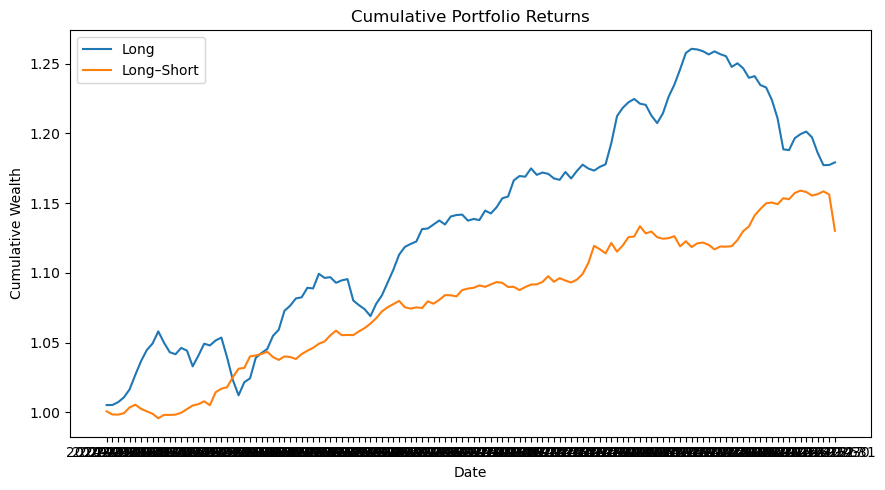

In [94]:
# Plot cumulative return (Long vs Long–Short)
cum_long = (1 + long_daily.fillna(0)).cumprod()
cum_ls   = (1 + ls_daily.fillna(0)).cumprod()

plt.figure(figsize=(9, 5))
plt.plot(cum_long.index, cum_long, label="Long")
plt.plot(cum_ls.index, cum_ls, label="Long–Short")
plt.title("Cumulative Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig("Figures/cumulative_portfolio_returns.png", 
            dpi=300, bbox_inches="tight")

plt.show()
plt.close()

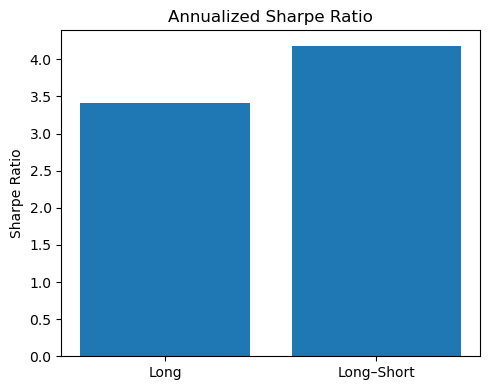

In [95]:
# Plot sharpe ratio comparison (Long vs Long–Short)
sharpe_vals = [
    stats_long["Annualized Sharpe Ratio"],
    stats_ls["Annualized Sharpe Ratio"]
]

plt.figure(figsize=(5, 4))
plt.bar(["Long", "Long–Short"], sharpe_vals)
plt.title("Annualized Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()

# Save figure
plt.savefig("Figures/annualized_sharpe_ratio.png",
            dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [96]:
# Load daily Fama–French 5-factor data from the Fama–French Data Library
df_factors = pd.read_csv(
    "F-F_Research_Data_5_Factors_2x3_daily.csv",
    skiprows=3  
)
df_factors

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
0,19630701,-0.67,0.00,-0.34,-0.01,0.16,0.01
1,19630702,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,19630703,0.63,-0.17,-0.09,0.18,-0.34,0.01
3,19630705,0.40,0.08,-0.27,0.09,-0.34,0.01
4,19630708,-0.63,0.04,-0.18,-0.29,0.14,0.01
...,...,...,...,...,...,...,...
15705,20251124,1.61,0.05,-0.96,-1.08,-1.57,0.02
15706,20251125,1.04,1.58,0.04,-0.09,0.36,0.02
15707,20251126,0.69,-0.01,-0.07,-0.35,-0.06,0.02
15708,20251128,0.54,-0.35,0.36,-0.73,-0.01,0.02


In [97]:
# Rename the "Unnamed: 0" column to date
df_factors = df_factors.rename(columns={df_factors.columns[0]: "date"})

# Only keep the dates that has date info (keep the form YYYYMMDD)
df_factors["date"] = df_factors["date"].astype(str).str.strip()
df_factors = df_factors[df_factors["date"].str.fullmatch(r"\d{8}")].copy()

# Transfer the date column to proper format
df_factors["date"] = pd.to_datetime(df_factors["date"], format="%Y%m%d")

# Fama-French factors are in %, need to  /100
df_factors.columns = [c.strip() for c in df_factors.columns]

for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
    df_factors[col] = pd.to_numeric(df_factors[col], errors="coerce") / 100

df_factors = df_factors.rename(columns={"Mkt-RF": "MKT_RF"})

df_factors

,date,MKT_RF,SMB,HML,RMW,CMA,RF
0,1963-07-01,-0.0067,0.0000,-0.0034,-0.0001,0.0016,0.0001
1,1963-07-02,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0001
2,1963-07-03,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0001
3,1963-07-05,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0001
4,1963-07-08,-0.0063,0.0004,-0.0018,-0.0029,0.0014,0.0001
...,...,...,...,...,...,...,...
15704,2025-11-21,0.0103,0.0185,0.0074,0.0009,0.0095,0.0002
15705,2025-11-24,0.0161,0.0005,-0.0096,-0.0108,-0.0157,0.0002
15706,2025-11-25,0.0104,0.0158,0.0004,-0.0009,0.0036,0.0002
15707,2025-11-26,0.0069,-0.0001,-0.0007,-0.0035,-0.0006,0.0002


In [98]:
df_ls = ls_daily.reset_index() # ls: long-short
df_ls.columns = ["date", "RET_LS"] 

df_l = long_daily.reset_index() # l: long-only
df_l.columns = ["date", "RET_L"]

df_l['date'] = pd.to_datetime(df_l['date'])
df_ls['date'] = pd.to_datetime(df_ls['date'])

df_ls = df_ls.merge(df_factors, on="date", how="inner")
df_l  = df_l.merge(df_factors, on="date", how="inner")

In [99]:
df_ls

,date,RET_LS,MKT_RF,SMB,HML,RMW,CMA,RF
0,2024-07-01,0.000630,0.0023,-0.0106,-0.0048,0.0048,-0.0034,0.0002
1,2024-07-02,-0.002223,0.0057,-0.0047,0.0040,0.0048,-0.0061,0.0002
2,2024-07-03,-0.000157,0.0048,-0.0029,-0.0069,-0.0001,0.0058,0.0002
3,2024-07-05,0.001055,0.0048,-0.0080,-0.0143,-0.0034,-0.0103,0.0002
4,2024-07-08,0.004123,0.0010,0.0052,-0.0019,-0.0032,0.0047,0.0002
...,...,...,...,...,...,...,...,...
123,2024-12-24,-0.002223,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,0.0002
124,2024-12-26,0.000900,0.0001,0.0107,-0.0018,-0.0042,0.0036,0.0002
125,2024-12-27,0.001706,-0.0117,-0.0044,0.0057,0.0039,0.0004,0.0002
126,2024-12-30,-0.001895,-0.0109,0.0025,0.0074,0.0055,0.0014,0.0002


In [100]:
df_l

,date,RET_L,MKT_RF,SMB,HML,RMW,CMA,RF
0,2024-07-01,0.005120,0.0023,-0.0106,-0.0048,0.0048,-0.0034,0.0002
1,2024-07-02,0.000070,0.0057,-0.0047,0.0040,0.0048,-0.0061,0.0002
2,2024-07-03,0.002008,0.0048,-0.0029,-0.0069,-0.0001,0.0058,0.0002
3,2024-07-05,0.003414,0.0048,-0.0080,-0.0143,-0.0034,-0.0103,0.0002
4,2024-07-08,0.005695,0.0010,0.0052,-0.0019,-0.0032,0.0047,0.0002
...,...,...,...,...,...,...,...,...
123,2024-12-24,-0.003430,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,0.0002
124,2024-12-26,-0.009374,0.0001,0.0107,-0.0018,-0.0042,0.0036,0.0002
125,2024-12-27,-0.007400,-0.0117,-0.0044,0.0057,0.0039,0.0004,0.0002
126,2024-12-30,0.000113,-0.0109,0.0025,0.0074,0.0055,0.0014,0.0002


In [101]:
# excess return
df_ls["excess_ret"] = df_ls["RET_LS"] - df_ls["RF"] 
df_l["excess_ret"] = df_l["RET_L"] - df_l["RF"]

## CAPM Regression

In [102]:
# CAPM
X_capm_ls = sm.add_constant(df_ls[["MKT_RF"]])
y_ls = df_ls["excess_ret"]
X_capm_l = sm.add_constant(df_ls[["MKT_RF"]])
y_l = df_l["excess_ret"]

capm_ls = sm.OLS(y_ls, X_capm_ls).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
capm_ls.summary()

# Save the result
capm_ls_df = pd.DataFrame({
    "coef": capm_ls.params,
    "std_err": capm_ls.bse,
    "t_stat": capm_ls.tvalues,
    "p_value": capm_ls.pvalues
})

capm_ls_df.to_csv("Tables/capm_long_short_coefficients.csv")

In [103]:
capm_l = sm.OLS(y_l, X_capm_l).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
capm_l.summary()

# Save the result
capm_l_df = pd.DataFrame({
    "coef": capm_l.params,
    "std_err": capm_l.bse,
    "t_stat": capm_l.tvalues,
    "p_value": capm_l.pvalues
})

capm_l_df.to_csv("Tables/capm_long_only_coefficients.csv")

## Fama–French Three-Factor Regression

In [104]:
#FF3
X_ff3_ls = sm.add_constant(df_ls[["MKT_RF", "SMB", "HML"]])
X_ff3_l = sm.add_constant(df_l[["MKT_RF", "SMB", "HML"]])

ff3_ls = sm.OLS(y_ls, X_ff3_ls).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
ff3_ls.summary()

# Save the result
ff3_ls_coef = pd.DataFrame({
    "coef": ff3_ls.params,
    "std_err": ff3_ls.bse,
    "t_stat": ff3_ls.tvalues,
    "p_value": ff3_ls.pvalues
})

ff3_ls_coef.to_csv("Tables/ff3_long_short_coefficients.csv")

In [105]:
ff3_l = sm.OLS(y_l, X_ff3_l).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
ff3_l.summary()

# Save the result
ff3_l_coef = pd.DataFrame({
    "coef": ff3_l.params,
    "std_err": ff3_l.bse,
    "t_stat": ff3_l.tvalues,
    "p_value": ff3_l.pvalues
})

ff3_l_coef.to_csv("Tables/ff3_long_only_coefficients.csv")

## Fama–French Five-Factor Regression

In [106]:
# FF5
X_ff5_ls = sm.add_constant(df_ls[["MKT_RF", "SMB", "HML", "RMW", "CMA"]])
X_ff5_l = sm.add_constant(df_l[["MKT_RF", "SMB", "HML", "RMW", "CMA"]])

ff5_ls = sm.OLS(y_ls, X_ff5_ls).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
ff5_ls.summary()

# Save the result
ff5_ls_coef = pd.DataFrame({
    "coef": ff5_ls.params,
    "std_err": ff5_ls.bse,
    "t_stat": ff5_ls.tvalues,
    "p_value": ff5_ls.pvalues
})

ff5_ls_coef.to_csv("Tables/ff5_long_short_coefficients.csv")

In [107]:
ff5_l = sm.OLS(y_l, X_ff5_l).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
ff5_l.summary()

# Save the result
ff5_l_coef = pd.DataFrame({
    "coef": ff5_l.params,
    "std_err": ff5_l.bse,
    "t_stat": ff5_l.tvalues,
    "p_value": ff5_l.pvalues
})

ff5_ls_coef.to_csv("Tables/ff5_long_only_coefficients.csv")

In [108]:
# alpha
def extract_alpha(model, freq=252):
    # daily alpha
    alpha_daily = model.params["const"]
    # annualized alpha
    alpha_ann = alpha_daily * freq
    # t-statisctics
    alpha_t = model.tvalues["const"]
    return alpha_daily, alpha_ann, alpha_t

In [109]:
alpha_table_ls = pd.DataFrame(
    {
        "CAPM": extract_alpha(capm_ls),
        "FF3":  extract_alpha(ff3_ls),
        "FF5":  extract_alpha(ff5_ls),
    },
    index=["Alpha (daily)", "Alpha (annualized)", "t-stat"]
)

alpha_table_ls

,CAPM,FF3,FF5
Alpha (daily),0.000765,0.000769,0.000759
Alpha (annualized),0.192749,0.193904,0.191163
t-stat,2.100091,2.203478,2.240874


In [110]:
alpha_table_l = pd.DataFrame(
    {
        "CAPM": extract_alpha(capm_l),
        "FF3":  extract_alpha(ff3_l),
        "FF5":  extract_alpha(ff5_l),
    },
    index=["Alpha (daily)", "Alpha (annualized)", "t-stat"]
)

alpha_table_l

,CAPM,FF3,FF5
Alpha (daily),0.001094,0.001085,0.001098
Alpha (annualized),0.275789,0.273503,0.276612
t-stat,1.513029,1.507855,1.542196


In [111]:
alpha_table_l.columns = pd.MultiIndex.from_product(
    [["Long-only"], alpha_table_l.columns]
)

alpha_table_ls.columns = pd.MultiIndex.from_product(
    [["Long–Short"], alpha_table_ls.columns]
)
alpha_all = pd.concat([alpha_table_l, alpha_table_ls], axis=1)
alpha_all.to_csv("tables/alpha_summary_combined.csv")
alpha_all

Long-only                     Long–Short            \
                        CAPM       FF3       FF5       CAPM       FF3   
Alpha (daily)       0.001094  0.001085  0.001098   0.000765  0.000769   
Alpha (annualized)  0.275789  0.273503  0.276612   0.192749  0.193904   
t-stat              1.513029  1.507855  1.542196   2.100091  2.203478   

                              
                         FF5  
Alpha (daily)       0.000759  
Alpha (annualized)  0.191163  
t-stat              2.240874

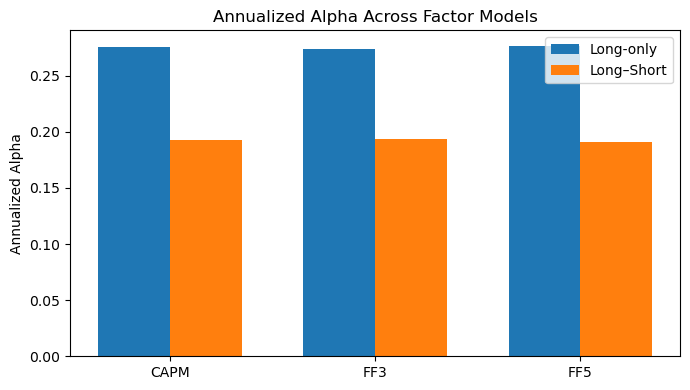

In [112]:
# Plot annualized alpha comparison: Long-only vs Long–Short
alpha_ann = alpha_all.loc["Alpha (annualized)"]

alpha_long = alpha_ann["Long-only"]
alpha_ls   = alpha_ann["Long–Short"]

x = np.arange(len(alpha_long.index))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, alpha_long.values, width, label="Long-only")
plt.bar(x + width/2, alpha_ls.values, width, label="Long–Short")

plt.xticks(x, alpha_long.index)
plt.ylabel("Annualized Alpha")
plt.title("Annualized Alpha Across Factor Models")
plt.legend()
plt.tight_layout()
plt.savefig("Figures/annualized_alpha_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [27]:
# just to make the table more readable
alpha_all_fmt = alpha_all.copy()
alpha_all_fmt.loc["Alpha (daily)"] *= 100
alpha_all_fmt.loc["Alpha (annualized)"] *= 100
alpha_all_fmt = alpha_all_fmt.round(3)
alpha_all_fmt

Long-only                 Long–Short                
                        CAPM     FF3     FF5       CAPM     FF3     FF5
Alpha (daily)          0.109   0.109   0.110      0.076   0.077   0.076
Alpha (annualized)    27.579  27.350  27.661     19.275  19.390  19.116
t-stat                 1.513   1.508   1.542      2.100   2.203   2.241

## Fama–MacBeth Regression
The trading strategy relies on a binary sentiment signal (−1 and +1), which is intentionally designed to focus on stronger signals and improve the Sharpe ratio.

Since the Fama–MacBeth regression requires sufficient cross-sectional variation, we additionally form test portfolios by sorting stocks on market capitalization (Size = Price × Shares Outstanding) and sentiment. This allows us to conduct the cross-sectional pricing test without changing the underlying trading logic.

In [ ]:
df = pd.read_csv("daily_sentiment_return.csv")

In [120]:
df["date"] = pd.to_datetime(df["date"])

# Sort by ticker and date to make shift(-1) correct
df = df.sort_values(["TICKER", "date"]).copy()
df["RET_t_plus_1"] = df.groupby("TICKER")["RET"].shift(-1)

df = df.dropna(subset=["RET_t_plus_1"]).copy()

# Keep only strong sentiment signals (-1 and +1), consistent with the trading rule
df = df[df["sentiment_daily"].isin([-1, 1])].copy()

# 1) Sort stocks into 5 size portfolios (size quintiles) based on market capitalization each day
df["size_grp"] = df.groupby("date")["MV_USD"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1
)

# 2) Create two sentiment groups: low (-1) and high (+1)
df["sent_grp"] = df["sentiment_daily"].map({-1: 1, 1: 2})

# 3) Combine size and sentiment groups to form 10 test portfolios
df["port_id"] = df["size_grp"].astype(str) + "_" + df["sent_grp"].astype(str)

# 4) Compute equal-weighted next-period returns (t+1) for each portfolio on each date (signal date t)
port_ret = (
    df.groupby(["date", "port_id"])["RET_t_plus_1"]
      .mean()
      .reset_index()
      .rename(columns={"RET_t_plus_1": "ret_t_plus_1"})
)

factor_cols_ff5 = ["MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]

ff = df_factors[["date"] + factor_cols_ff5].drop_duplicates("date")

panel = port_ret.merge(ff, on="date", how="left")

# Check the share of observations with missing factor information
miss = panel["MKT_RF"].isna().mean()
print("Share of missing factor rows:", miss)

# Compute excess returns using next-period portfolio returns
panel["excess_ret_t_plus_1"] = panel["ret_t_plus_1"] - panel["RF"]

# Drop the NAs
panel = panel.dropna(subset=["excess_ret_t_plus_1", "MKT_RF", "SMB", "HML", "RMW", "CMA"])

Share of missing factor rows: 0.0


In [121]:
def fama_macbeth_two_step(panel, port_col="port_id", time_col="date",
                          ret_col="excess_ret_t_plus_1",
                          factor_cols=("MKT_RF","SMB","HML","RMW","CMA"),
                          nw_lags=3, min_obs_ts=24):
    panel = panel.copy().sort_values([port_col, time_col])

    # Step 1: time-series regression per portfolio -> betas
    betas = []
    for pid, g in panel.groupby(port_col):
        g = g.dropna(subset=[ret_col, *factor_cols])
        if len(g) < min_obs_ts:
            continue
        X = sm.add_constant(g[list(factor_cols)])
        y = g[ret_col]
        res = sm.OLS(y, X).fit()
        row = {port_col: pid}
        for f in factor_cols:
            row[f"beta_{f}"] = res.params[f]
        betas.append(row)

    betas = pd.DataFrame(betas)
    if betas.empty:
        raise ValueError("Not enough observations per portfolio to estimate betas. "
                         "Try lowering min_obs_ts (e.g., 12) or ensure each port has enough dates.")

    df2 = panel.merge(betas, on=port_col, how="inner")
    beta_cols = [f"beta_{f}" for f in factor_cols]

    # Step 2: cross-sectional regression each date -> lambdas
    lambdas = []
    for t, g in df2.groupby(time_col):
        g = g.dropna(subset=[ret_col, *beta_cols])
        if len(g) < (len(beta_cols) + 2):
            continue
        Xcs = sm.add_constant(g[beta_cols])
        ycs = g[ret_col]
        rcs = sm.OLS(ycs, Xcs).fit()
        out = {time_col: t, "lambda_const": rcs.params["const"]}
        for b in beta_cols:
            out[f"lambda_{b.replace('beta_','')}"] = rcs.params[b]
        lambdas.append(out)

    lambdas = pd.DataFrame(lambdas)
    if lambdas.empty:
        raise ValueError("Not enough portfolios per date for Step 2. "
                         "Make sure you have ~10 portfolios each date.")

    # Newey-West on average lambdas
    rows = []
    for col in [c for c in lambdas.columns if c != time_col]:
        s = lambdas[col].dropna().values
        X = np.ones(len(s))
        res = sm.OLS(s, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
        rows.append({
            "parameter": col,
            "mean_lambda": res.params[0],
            "hac_se": res.bse[0],
            "t_stat": res.tvalues[0],
            "p_value": res.pvalues[0],
            "T": len(s)
        })

    summary = pd.DataFrame(rows).sort_values("parameter")
    return betas, lambdas, summary

In [122]:
# FF3
betas_ff3, lambdas_ff3, fmb_sum_ff3 = fama_macbeth_two_step(
    panel,
    factor_cols=("MKT_RF","SMB","HML"),
    nw_lags=3,
    min_obs_ts=12
)
fmb_sum_ff3.to_csv("tables/fama_macbeth_ff3_summary.csv", index=False)
fmb_sum_ff3

,parameter,mean_lambda,hac_se,t_stat,p_value,T
3,lambda_HML,-0.000183,0.002418,-0.075858,0.939532,127
1,lambda_MKT_RF,0.001140,0.006403,0.178115,0.858633,127
2,lambda_SMB,0.001847,0.003682,0.501548,0.615986,127
0,lambda_const,0.000523,0.000817,0.640768,0.521673,127


In [123]:
# FF5
betas_ff5, lambdas_ff5, fmb_sum_ff5 = fama_macbeth_two_step(
    panel,
    port_col="port_id",
    time_col="date",
    ret_col="excess_ret_t_plus_1",
    factor_cols=("MKT_RF","SMB","HML","RMW","CMA"),
    nw_lags=3,
    min_obs_ts=12   
)
fmb_sum_ff5.to_csv("tables/fama_macbeth_ff5_summary.csv", index=False)
fmb_sum_ff5

,parameter,mean_lambda,hac_se,t_stat,p_value,T
5,lambda_CMA,-0.005589,0.003475,-1.608286,0.107772,127
3,lambda_HML,-0.005953,0.003285,-1.812043,0.069979,127
1,lambda_MKT_RF,-0.002237,0.006521,-0.342981,0.731613,127
4,lambda_RMW,0.002286,0.003087,0.740442,0.459032,127
2,lambda_SMB,-0.001971,0.003997,-0.493124,0.621925,127
0,lambda_const,0.002055,0.000755,2.720837,0.006512,127
